# BAB 11 — NOVELTY AND OUTLIER DETECTION

## 11.1 Pengenalan

Outlier adalah data yang memiliki pola berbeda jauh dari sebagian besar data.

Contoh:

Data nilai:

70, 72, 75, 71, 73, 150

Angka 150 dapat dianggap sebagai outlier.

Outlier detection digunakan untuk mencari data yang menyimpang.

Contoh penggunaan:

- fraud detection
- network intrusion
- kerusakan mesin
- transaksi tidak normal
- sensor abnormal

Beberapa algoritma:

- Isolation Forest
- One-Class SVM
- Local Outlier Factor

## 11.2 Isolation Forest

Isolation Forest bekerja dengan cara mengisolasi data.

Data yang berbeda dari mayoritas biasanya lebih mudah dipisahkan.

Parameter utama:

contamination = perkiraan proporsi outlier dalam data.

In [1]:
from sklearn.datasets import make_blobs
from sklearn.ensemble import IsolationForest
import numpy as np

X, _ = make_blobs(
    n_samples=300,
    centers=1,
    cluster_std=1,
    random_state=42
)

outliers = np.array([
    [6, 6],
    [7, 7],
    [8, 8]
])

X = np.vstack([X, outliers])

model = IsolationForest(
    contamination=0.02,
    random_state=42
)

pred = model.fit_predict(X)

print(pred)

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1 -1 -1 -1]


Hasil prediksi:

1 → data normal

-1 → outlier

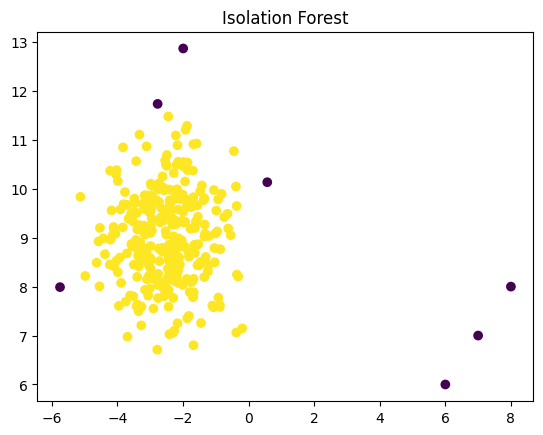

In [2]:
import matplotlib.pyplot as plt

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=pred
)

plt.title("Isolation Forest")
plt.show()

import matplotlib.pyplot as plt

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=pred
)

plt.title("Isolation Forest")
plt.show()

## 11.3 One-Class SVM

One-Class SVM mempelajari pola data normal.

Setelah itu, data yang terlalu jauh dari pola tersebut dapat dianggap sebagai anomaly.

One-Class SVM sering digunakan untuk novelty detection.

In [4]:
from sklearn.svm import OneClassSVM

model = OneClassSVM(
    kernel="rbf",
    gamma="auto",
    nu=0.02
)

pred = model.fit_predict(X)

print(pred)

[ 1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1 -1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
 -1  1  1  1  1  1 -1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1 -1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1 -1  1  1  1
  1  1  1  1  1 -1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1
  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1]


## 11.4 Local Outlier Factor

Local Outlier Factor atau LOF membandingkan kepadatan suatu data dengan tetangganya.

Jika suatu titik memiliki kepadatan yang jauh lebih rendah dibandingkan tetangganya, titik tersebut dapat dianggap sebagai outlier.

In [5]:
from sklearn.neighbors import LocalOutlierFactor

model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.02
)

pred = model.fit_predict(X)

print(pred)

[ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1
  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1 -1 -1 -1]


## 11.5 Membandingkan Hasil

Ketiga algoritma dapat memberikan hasil yang berbeda.

Isolation Forest:
- menggunakan konsep isolasi.
- cocok untuk dataset yang cukup besar.

One-Class SVM:
- mempelajari batas data normal.
- dapat menggunakan kernel.

LOF:
- melihat kepadatan lokal.
- berguna ketika outlier berbeda dari tetangganya.

## 11.6 Kesimpulan Bab 11

Pada bab ini kita mempelajari:

- Outlier.
- Anomaly detection.
- Novelty detection.
- Isolation Forest.
- One-Class SVM.
- Local Outlier Factor.

Tujuan utamanya adalah menemukan data yang memiliki pola berbeda dari data normal.